# HOMEWORK 2
For this homework you will have to complete and implement the colour balancing for:
* Gray world algorithm
* Scale-by-max algorithm

You are free to use your own images. Experiment with more images and think about the effect each of the algorithms has on the resulting (balanced) image.

### Colour Balancing
In this notebook we will show different type of colour balancing making use of von Kries' hypothesis.

In [83]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 5]

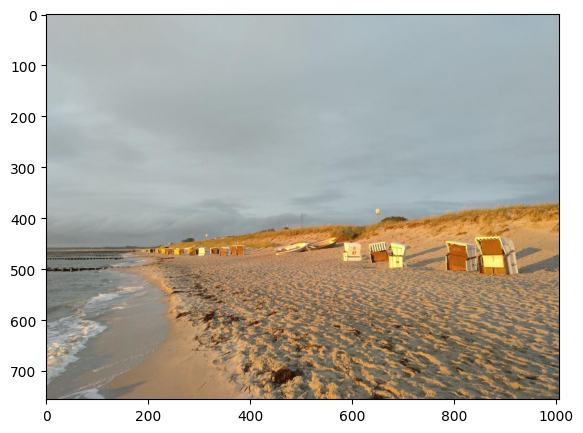

In [84]:
img = cv2.imread('sea.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

### White patch
In white patch algorithm we choose a group of pixels we know they should be white. We then scale the resulting image colour channels by this white patch.

(<Axes: >, <matplotlib.image.AxesImage at 0x1586f9850>)

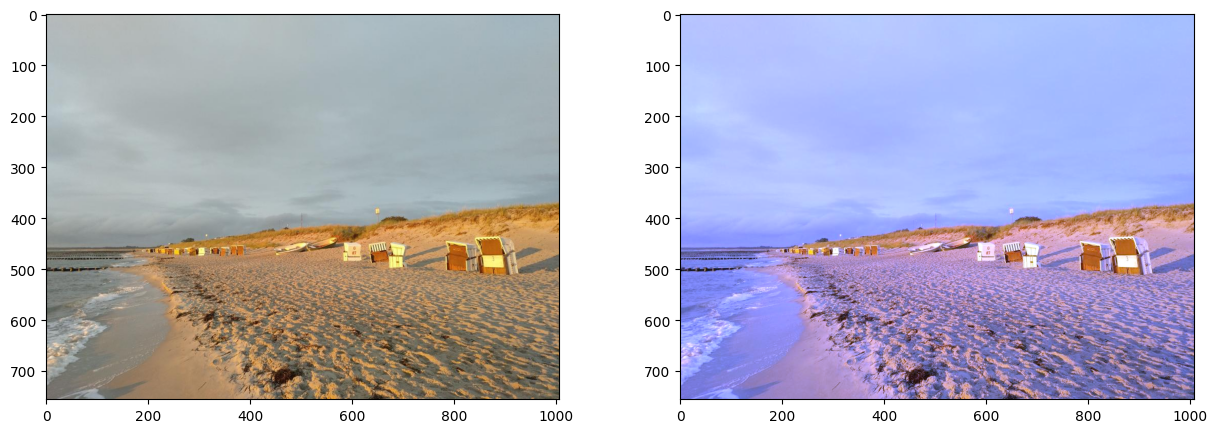

In [85]:
# Define white patch and the coefficients
row, col = 485, 864 
white = img[row, col, :]
coeffs = 255.0/white

# Apply white balancing and generate balanced image
balanced = np.zeros_like(img, dtype=np.float32)
for channel in range(3):
    balanced[..., channel] = img[..., channel] * coeffs[channel]

# White patching does not guarantee that the dynamic range is preserved, images must be clipped.
balanced = balanced/255
balanced[balanced > 1] = 1

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(balanced)

### Gray world
This algorithm assumes that a scene, on average, is gray.

((np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0)),
 <matplotlib.image.AxesImage at 0x15b880a40>)

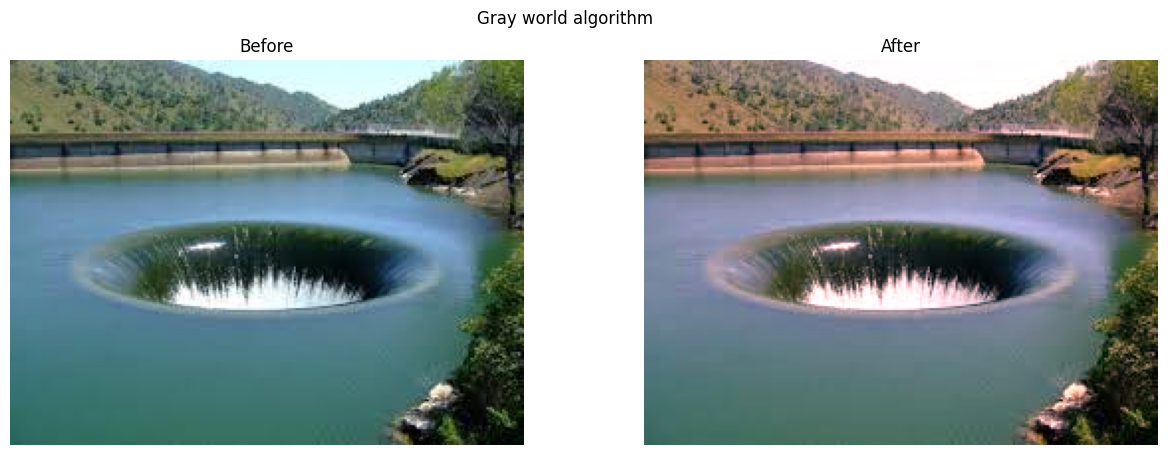

In [88]:
# Load your image
img = cv2.imread('funnel.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Compute the mean values for all three colour channels (red, green, blue)
rgb_channels = dict(zip(('r', 'g', 'b'), cv2.split(img)))

means = {color: matrix.mean() for (color, matrix) in rgb_channels.items()}
max_channel = max(means, key=means.get)

# Compute the coefficients kr, kg, kb
# Note: there are 3 coefficients to compute but we only have 2 equations.
# Therefore, you have to make an assumption, fix the value of one of the
# coefficients and compute the remining two
# Hint: You can fix the coefficient of the brightest colour channel to 1. 
k = {channel: means[max_channel]/mean for (channel, mean) in means.items()}

# Apply color balancing and generate the balanced image
balanced = np.clip(cv2.merge(
  tuple({color: matrix * k[color] for (color, matrix) in rgb_channels.items()}.values())
), 0, 255).astype(np.uint8)

# Show the original and the balanced image side by side
plt.suptitle('Gray world algorithm')
plt.subplot(121, title='Before').axis('off'), plt.imshow(img)
plt.subplot(122, title='After').axis('off'), plt.imshow(balanced)

### Scale-by-max
This is a straightforward algorithm that scales each colour channel by its maximum value. Note that it is sensitive to noise and saturations.

((np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0)),
 <matplotlib.image.AxesImage at 0x15b620380>)

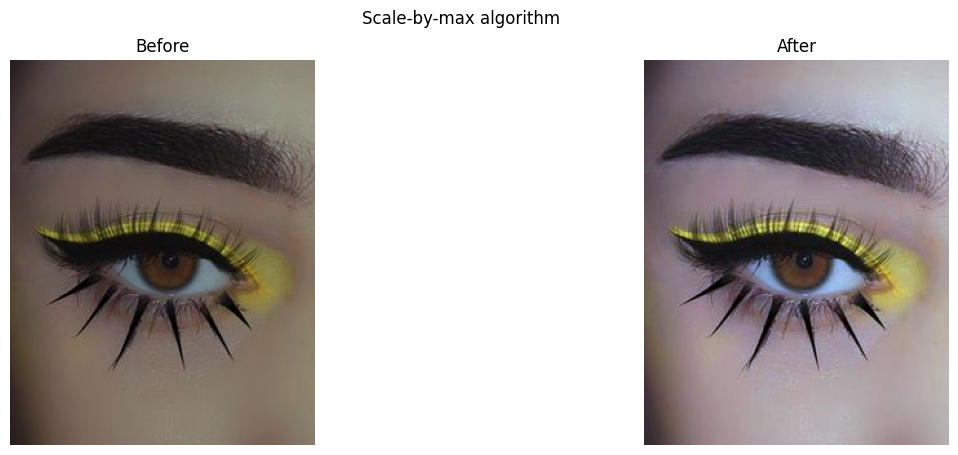

In [87]:
# Load your image
img = cv2.imread('eye.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

rgb_channels = dict(zip(('r', 'g', 'b'), cv2.split(img)))
# Compute the maximum values for all three colour channels (red, green, blue)
maxs = {color: matrix.max() for (color, matrix) in rgb_channels.items()}

# Apply scale-by-max balancing and generate the balanced image
balanced = cv2.merge(
  tuple({color: (matrix / maxs[color] * 255).clip(0, 255) for (color, matrix) in rgb_channels.items()}.values())
).astype(np.uint8)

plt.suptitle('Scale-by-max algorithm')
plt.subplot(121, title='Before').axis('off'), plt.imshow(img)
plt.subplot(122, title='After').axis('off'), plt.imshow(balanced)